In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. New UMI proportion (pie)

Control and treatment

In [3]:
# Load metrics
d = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
d = d[(d["Time"] == 3) & (d["ActD"].isna()) & (d["UMIs"] >= 5000)]
d1 = d[(d["CellType"] == "K562") & (d["s4U"] == 0)]
d2 = d[(d["CellType"] == "K562") & (d["s4U"] == 50) & (d["TC.Ratio"] >= 0.008) & (d["TC.Ratio"] < 1)]
d3 = d[(d["CellType"] == "mESC") & (d["s4U"] == 0)]
d4 = d[(d["CellType"] == "mESC") & (d["s4U"] == 400) & (d["TC.Ratio"] >= 0.01) & (d["TC.Ratio"] < 1)]
print(len(d1), len(d2), len(d3), len(d4))

190 105 64 110


0.36338905436008195	0.23471242376136747
99.6366109456399	0.2347124237613666
16.460616338123092	5.779640808143504
83.53938366187691	5.779640808143503
0.7999128927603394	0.26641523014699825
99.20008710723965	0.26641523014699753
46.71270823372869	8.285118873834264
53.28729176627131	8.285118873834264


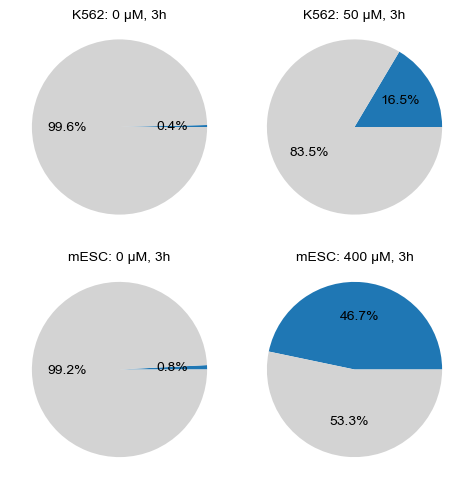

In [5]:
df_list = [d1, d2, d3, d4]
titles = ["K562: 0 μM, 3h", "K562: 50 μM, 3h", "mESC: 0 μM, 3h", "mESC: 400 μM, 3h"]
for i, df in enumerate(df_list):
    vs1 = df["mrUMIs.New.Ratio"] * 100 # get_ratios(df)
    vs2 = [100 - v for v in vs1]
    print(np.mean(vs1), np.std(vs1), sep="\t")
    print(np.mean(vs2), np.std(vs2), sep="\t")
    
fig, axs = plt.subplots(2, 2, figsize=(5, 5), sharex=True, sharey=True, gridspec_kw={"wspace": 0})
for i, df in enumerate(df_list):
    plt.sca(axs[i//2][i%2])
    # plt.title(titles[i])
    vs1 = df["mrUMIs.New.Ratio"] * 100 # get_ratios(df)
    vs2 = [100 - v for v in vs1]
    plt.pie([np.mean(vs1), np.mean(vs2)], 
            colors=["C0", "lightgrey"], 
            # labels=["%.1f±%.1f%%" % (np.mean(vs1), np.std(vs1)), "%.1f±%.1f%%" % (np.mean(vs2), np.std(vs2))], labeldistance=0.2,
            autopct='%.1f%%', pctdistance=0.6, 
            wedgeprops=dict(width=1))
    plt.text(0, 1.2, titles[i], ha="center", va="bottom")
plt.tight_layout()
plt.savefig("figures/new_rna_proportion.pie.pdf")
plt.show()
plt.close()

## 2. New UMI proportion (barplot)

Concentration: 100uM, 200uM, 400uM, 500uM

Time: 15min, 30min, 1h, 2h

In [2]:
infos = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
infos = infos[infos["UMIs"] > 5000]

In [8]:
df_list = []
ticks = []

df1 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 0) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df2 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 50) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df2 = df2[(df2["TC.Ratio"] > 0.008) & (df2["TC.Ratio"] < 0.02)]
df_list.extend([df1, df2])
ticks.extend(["0 μM\n3 h", "50 μM\n3 h"])

# time
df1 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 50) & (infos["Time"] == 0.25) & (infos["ActD"].isna())]
df2 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 50) & (infos["Time"] == 0.5) & (infos["ActD"].isna())]
df3 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 50) & (infos["Time"] == 1) & (infos["ActD"].isna())]
df4 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 50) & (infos["Time"] == 2) & (infos["ActD"].isna())]
df_list.extend([df1, df2, df3, df4])
ticks.extend(["50 μM\n15 min", "50 μM\n30 min", "50 μM\n1 h", "50 μM\n2 h"])

# actd
df1 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 0) & (infos["Time"] == 3) & (infos["ActD"] == 3)]
df2 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 50) & (infos["Time"] == 3) & (infos["ActD"] == 3)]
df3 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 0) & (infos["Time"] == 3) & (infos["ActD"] == 6)]
df4 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 50) & (infos["Time"] == 3) & (infos["ActD"] == 6)]
df_list.extend([df1, df2, df3, df4])
ticks.extend(["0 μM\n3 h", "50 μM\n3 h", "0 μM\n3 h", "50 μM\n3 h"])

# concentration
df1 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 100) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df2 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 200) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df3 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 400) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df4 = infos[(infos["CellType"] == "K562") & (infos["s4U"] == 500) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df_list.extend([df1, df2, df3, df4])
ticks.extend(["100 μM\n3 h", "200 μM\n3 h", "400 μM\n3 h", "500 μM\n3 h"])

# mESC
df1 = infos[(infos["CellType"] == "mESC") & (infos["s4U"] == 0) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df2 = infos[(infos["CellType"] == "mESC") & (infos["s4U"] == 50) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df3 = infos[(infos["CellType"] == "mESC") & (infos["s4U"] == 400) & (infos["Time"] == 3) & (infos["ActD"].isna())]
df3 = df3[(df3["TC.Ratio"] > 0.01) & (df3["TC.Ratio"] < 0.03)]

df_list.extend([df1, df2, df3])
ticks.extend(["0 μM\n3 h", "50 μM\n3 h", "400 μM\n3 h"])

190	0 μM, 3 h
99	50 μM, 3 h
32	50 μM, 15 min
51	50 μM, 30 min
41	50 μM, 1 h
44	50 μM, 2 h
68	0 μM, 3 h
63	50 μM, 3 h
81	0 μM, 3 h
59	50 μM, 3 h
19	100 μM, 3 h
11	200 μM, 3 h
17	400 μM, 3 h
23	500 μM, 3 h
64	0 μM, 3 h
79	50 μM, 3 h
107	400 μM, 3 h


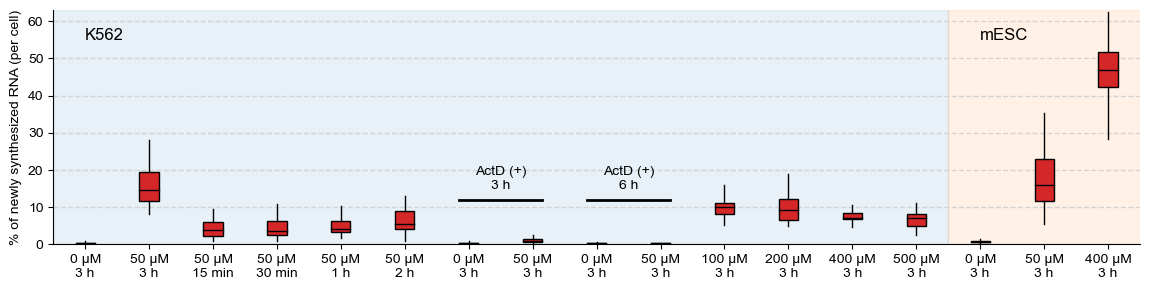

In [11]:
w = 0.3
plt.figure(figsize=(11.6, 3))
for i, df in enumerate(df_list):
    df = df[~df["mrUMIs.New.Ratio"].isna()]
    print(len(df), ticks[i].replace("\n", ", "), sep="\t")
    rs = df["mrUMIs.New.Ratio"] * 100
    plt.boxplot([rs], positions=[i], widths=w, 
                showfliers=False, showmeans=False,
                patch_artist=True, boxprops={"facecolor": "C3"},
                showcaps=False, medianprops={"color": "black"})
xs = np.arange(len(df_list))

x1, x2 = 6, 7
y = 12
plt.plot([x1 - w/2, x2 + w/2], [y, y], lw=2, color="black")
plt.text((x1 + x2)/2, y + 3, "ActD (+)\n3 h", ha="center")

x1, x2 = 8, 9
y = 12
plt.plot([x1 - w/2, x2 + w/2], [y, y], lw=2, color="black")
plt.text((x1 + x2)/2, y + 3, "ActD (+)\n6 h", ha="center")

# plt.axvline(13.5, lw=1, color="black")
plt.axvspan(-0.5, 13.5, color="C0", alpha=0.1)
plt.axvspan(13.5, 16.5, color="C1", alpha=0.1)

plt.text(0, 55, "K562", ha="left", size=12)
plt.text(14, 55, "mESC", ha="left", size=12)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(xs, ticks, rotation=0, ha="center")
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.ylim(0, 63)
plt.ylabel("% of newly synthesized RNA (per cell)")
plt.grid(axis="y", lw=1, ls="--", color="lightgrey")
plt.tight_layout()

plt.savefig("figures/nascent_rna_proportion.bar.all_condition.pdf")
plt.show()
plt.close()